# Multiple Orbits

galpy's `Orbit` class natively handles multiple orbits at once,
enabling efficient parallel integration and vectorized access to
orbital quantities.

For basic orbit initialization, see [Orbit Initialization](initialization.ipynb).

In [1]:
%matplotlib inline
import numpy
from astropy import units
from astropy.coordinates import SkyCoord
from galpy.orbit import Orbit
from galpy.potential import MWPotential2014

## Array initialization

Pass a 2D array of shape `(N, dim)` to create N orbits at once.

In [2]:
numpy.random.seed(42)
N = 10
vxvvs = numpy.column_stack(
    [
        numpy.random.uniform(0.8, 1.2, N),  # R
        numpy.random.normal(0.0, 0.05, N),  # vR
        numpy.random.uniform(0.9, 1.1, N),  # vT
        numpy.random.normal(0.0, 0.05, N),  # z
        numpy.random.normal(0.0, 0.05, N),  # vz
        numpy.random.uniform(0.0, 2 * numpy.pi, N),  # phi
    ]
)
os = Orbit(vxvvs)
print("Number of orbits:", os.size)
print("Shape:", os.shape)
print("R values:", os.R())

Number of orbits: 10
Shape: (10,)
R values: [0.94981605 1.18028572 1.09279758 1.03946339 0.86240746 0.86239781
 0.82323344 1.14647046 1.040446   1.08322903]


## Initialization from SkyCoord arrays

You can pass a `SkyCoord` containing multiple objects.

In [3]:
sc = SkyCoord(
    ra=[20.0, 50.0, 100.0] * units.deg,
    dec=[30.0, -10.0, 45.0] * units.deg,
    distance=[1.5, 3.0, 0.8] * units.kpc,
    pm_ra_cosdec=[3.5, -1.0, 2.0] * units.mas / units.yr,
    pm_dec=[-1.2, 0.5, -0.3] * units.mas / units.yr,
    radial_velocity=[15.0, -30.0, 50.0] * units.km / units.s,
)
os_sc = Orbit(sc)
print("Number of orbits:", os_sc.size)
print("RA values:", os_sc.ra())

Number of orbits: 3
RA values: [ 20.  50. 100.]


## List initialization

A list of phase-space arrays also works.

In [4]:
os_list = Orbit(
    [
        [1.0, 0.1, 1.0, 0.0, 0.05, 0.0],
        [0.9, -0.05, 1.1, 0.02, -0.03, 1.0],
    ]
)
print("Size:", os_list.size)
print("R:", os_list.R())

Size: 2
R: [1.  0.9]


## Shape, len, size, and reshape

Multi-orbit objects behave like arrays.

In [5]:
os_many = Orbit(vxvvs)
print("len:", len(os_many))
print("size:", os_many.size)
print("shape:", os_many.shape)

# Reshape to (2, 5) -- reshape is done in-place
os_many.reshape((2, 5))
print("Reshaped shape:", os_many.shape)

len: 10
size: 10
shape: (10,)
Reshaped shape: (2, 5)


## Slicing and indexing

Indexing and slicing returns a new `Orbit` object.

In [6]:
# Single orbit (from the flat os object)
os_flat = Orbit(vxvvs)
o_single = os_flat[3]
print("Single orbit:", o_single)
print("Size:", o_single.size)

# Slice
o_slice = os_flat[2:5]
print("Slice size:", o_slice.size)

# 2D indexing on reshaped
o_2d = os_many[1, 2]
print("2D indexed orbit R:", o_2d.R())

Single orbit: <galpy.orbit.Orbits.Orbit object at 0x7f4420b9cdd0>
Size: 1
Slice size: 3
2D indexed orbit R: 1.146470458309974


## Output shapes are preserved

When you access quantities from a multi-orbit object, the output
has the same shape as the orbit array.

In [7]:
print("R shape (flat):", os_flat.R().shape)
print("R shape (reshaped):", os_many.R().shape)

R shape (flat): (10,)
R shape (reshaped): (2, 5)


## Array `ro` and `vo` inputs

You can pass arrays for `ro` and `vo` when initializing multiple orbits
with observed coordinates, though typically a single value is used.

In [8]:
os_phys = Orbit(vxvvs, ro=8.0, vo=220.0)
print("R (physical):", os_phys.R())
print("Units: kpc")

R (physical): [7.59852838 9.44228578 8.74238061 8.31570715 6.89925965 6.89918247
 6.58586756 9.17176367 8.32356804 8.66583225]
Units: kpc


## Integrating and plotting multiple orbits

  0%|          | 0/10 [00:00<?, ?it/s]

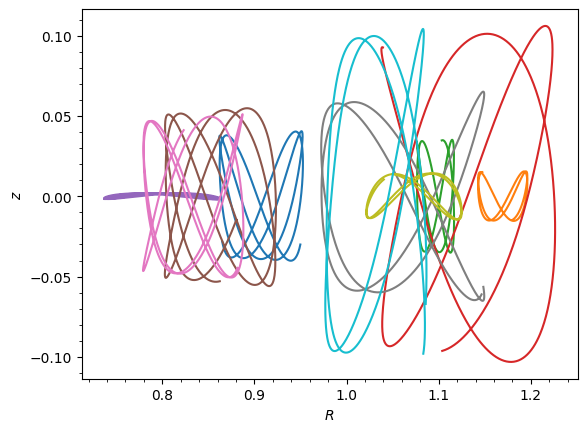

In [9]:
from matplotlib import pyplot as plt

# Integrate all 10 orbits and plot them
os_plot = Orbit(vxvvs)
ts = numpy.linspace(0.0, 10.0, 1001)
os_plot.integrate(ts, MWPotential2014)
os_plot.plot()